# S&P 500 multivariate forecasting — backtest demo

This notebook is the **presentation-style** entry point for the leak-safe
multivariate S&P 500 experiment: same target as the single-variable path
(`sp500_log_ret_1b`), with optional macro and cross-asset covariates registered
on one `DataService`.

**What you get in this notebook**

1. A quick **observed-history** figure for the target log return (context for the score).
2. A plain-text **`describe_spec()`** summary of the active `BacktestSpec` (the
   Canada food CPI notebook prints YAML-backed specs the same way).
3. A unified **`RESULTS_DF`** leaderboard: mean CRPS, covariate usage, **direction**
   metrics (point sign vs realised sign; ROC on `prob_up` from quantiles).
4. A **formatted table** plus a **mean CRPS bar chart** for slides.

---

**How to run:** edit **DEMO CONFIG** (section 2), then **Run All**.  The
multivariate README documents prerequisites and the no-leakage contract.



---
## 1. Setup

Heavy lifting lives in Python modules next to this notebook:

- `data.py` — `build_sp500_multivariate_service()`, covariate series ids, lagging policy.
- `plots.py` — matplotlib figures (target history, CRPS bars).
- `analysis.py` — `style_results_dataframe()` for readable leaderboards.
- `stock_price_forecasting_single_variable/analysis.py` — shared direction helpers.

Predictors are imported from `implementations/methods/darts_regression.py`.



In [13]:
from __future__ import annotations

import os
import sys
from pathlib import Path


def _bootstrap_sys_path() -> Path:
    if os.environ.get("AIENG_REPO_ROOT"):
        root = Path(os.environ["AIENG_REPO_ROOT"]).expanduser().resolve()
        if (root / "aieng-forecasting").is_dir() and (root / "implementations").is_dir():
            for sub in (root, root / "aieng-forecasting", root / "implementations"):
                s = str(sub)
                if s not in sys.path:
                    sys.path.insert(0, s)
            return root

    seeds: list[Path] = []
    try:
        from IPython import get_ipython

        ip = get_ipython()
        if ip is not None:
            nb = ip.user_ns.get("__vsc_ipynb_file__")
            if nb:
                seeds.append(Path(nb).resolve().parent)
    except Exception:
        pass

    for env_key in ("PWD", "INIT_CWD", "OLDPWD"):
        v = os.environ.get(env_key)
        if v:
            try:
                seeds.append(Path(v).expanduser().resolve())
            except (OSError, ValueError):
                pass

    seeds.append(Path.cwd().resolve())

    for seed in seeds:
        for p in (seed, *seed.parents):
            if (p / "aieng-forecasting").is_dir() and (p / "implementations").is_dir():
                for sub in (p, p / "aieng-forecasting", p / "implementations"):
                    s = str(sub)
                    if s not in sys.path:
                        sys.path.insert(0, s)
                return p

    raise RuntimeError("Cannot find repo root. Pick the project's .venv kernel, or set AIENG_REPO_ROOT.")


REPO_ROOT = _bootstrap_sys_path()
REPO_ROOT


PosixPath('/Users/behnoosh/Library/Mobile Documents/com~apple~CloudDocs/aieng/agentic-forecasting')

---
## 2. Configuration (edit the next cell only)

`RUN_MODELS` toggles which rows appear in `RESULTS_DF`.

`SPEC_START` / `SPEC_END` are **forecast origins** (`as_of`): one full backtest fit
per business day in that inclusive range. For `horizons=[1]` and `frequency="B"`,
each scored prediction’s `forecast_date` is the **next** business session after
`as_of` (see `describe_spec` output).

`DATA_HISTORY_START` should be **well before** your first origin so lag features
and covariates look like production (e.g. years of history before COVID).
`SPEC_WARMUP` is the minimum **rows of target** required at each origin; use at
least ~one trading year (~252) for a realistic floor, not just the lag length.



In [14]:
# =============================================================================
# DEMO CONFIG — edit this cell only to choose models and the evaluation window
# =============================================================================

# Which rows appear in RESULTS_DF (True = run that backtest)
RUN_MODELS: dict[str, bool] = {
    "linreg_target_only": True,
    "linreg_with_covariates": True,
    "lightgbm_target_only": True,  # enable after `brew install libomp`; predictor caps threads to reduce segfaults
    "lightgbm_with_covariates": True,
    "arima_target_only": True,  # fixed-order Darts ARIMA (slower per origin than linreg)
    "varima_with_covariates": True,  # VARIMA on [target] + FAST_COVARIATE_SERIES_IDS (needs ≥1 covariate)
}

# --- Evaluation window (edit here) ------------------------------------------
# COVID crash study: business-day forecast *origins* from Apr through end of May 2020.
SPEC_START = "2020-03-01"
SPEC_END = "2021-03-01"
SPEC_STRIDE = 1  # 1 = every session in range; raise to thin for speed
# Require ~1 trading year of target history at each origin (realistic vs warmup=lags only)
SPEC_WARMUP = 252

# History back to 2000 so models see full pre-crisis macro + price path (leak-safe cutoffs per origin)
DATA_HISTORY_START = "2000-01-01"
REFRESH_CACHE = False

# Predictor knobs (raise for slower, higher-fidelity runs)
QUICK_LAGS = 5
QUICK_LAGS_PAST_COV = 5
QUICK_NUM_SAMPLES = 200

# Darts ARIMA / VARIMA orders (see `methods.darts_arima`)
QUICK_ARIMA_P, QUICK_ARIMA_D, QUICK_ARIMA_Q = 5, 0, 2
QUICK_VARIMA_P, QUICK_VARIMA_D, QUICK_VARIMA_Q = 1, 0, 1

# Covariates used for *_with_covariates runs (must exist in svc_cov after build)
FAST_COVARIATE_SERIES_IDS = [
    "vix_level_l1b",
    "vix_log_ret_1b_l1b",
    "nasdaq_log_ret_1b_l1b",
    "ust2y10y_spread_l1b",
]

SHOW_BACKTEST_PROGRESS = True

# Passed to Darts LightGBMModel (single-thread reduces some macOS crash modes)
LIGHTGBM_KWARGS: dict[str, object] = {"num_threads": 1, "n_jobs": 1, "verbosity": -1}



---
## 3. Imports



In [15]:
from __future__ import annotations

import warnings

import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore")

from aieng.forecasting.evaluation import (
    BacktestSpec,
    ForecastingTask,
    backtest,
    describe_spec,
)
from implementations.experiments.stock_price_forecasting_multivariate import (
    DEFAULT_COVARIATE_SERIES_IDS,
    SP500_LOG_RETURN_SERIES_ID,
    build_sp500_multivariate_service,
)
from implementations.experiments.stock_price_forecasting_multivariate.analysis import (
    style_results_dataframe,
)
from implementations.experiments.stock_price_forecasting_multivariate.plots import (
    plot_mean_crps_leaderboard,
    plot_sp500_log_return_recent,
)
from implementations.experiments.stock_price_forecasting_single_variable.analysis import (
    build_direction_eval_frame,
    direction_classification_metrics,
)
from methods.darts_arima import DartsARIMAPredictor, DartsVARIMAPredictor
from methods.darts_regression import DartsLightGBMPredictor, DartsLinearRegressionPredictor



---
## 4. Build data services

- **`svc_no_cov`** — target only (baseline).
- **`svc_cov`** — target plus every covariate that successfully registered
  (missing optional feeds are skipped with warnings unless you enable strict mode
  in `data.py`).



In [16]:
svc_no_cov = build_sp500_multivariate_service(
    include_covariates=False,
    start=DATA_HISTORY_START,
    end=None,
    refresh=REFRESH_CACHE,
)

svc_cov = build_sp500_multivariate_service(
    include_covariates=True,
    covariate_series_ids=DEFAULT_COVARIATE_SERIES_IDS,
    start=DATA_HISTORY_START,
    end=None,
    refresh=REFRESH_CACHE,
)

registered_covariates = [
    sid for sid in DEFAULT_COVARIATE_SERIES_IDS if sid in set(svc_cov.series_ids)
]
selected_covariates = [sid for sid in FAST_COVARIATE_SERIES_IDS if sid in registered_covariates]
if not selected_covariates:
    selected_covariates = registered_covariates

print("svc_no_cov:", svc_no_cov.series_ids)
print("svc_cov count:", len(svc_cov.series_ids))
print("selected covariates:", selected_covariates)



svc_no_cov: ['sp500_log_ret_1b']
svc_cov count: 11
selected covariates: ['vix_level_l1b', 'vix_log_ret_1b_l1b', 'nasdaq_log_ret_1b_l1b', 'ust2y10y_spread_l1b']


---
## 5. Target context — observed log returns

One panel of recent **realised** prior-close-to-next-open log returns (the same
series the models forecast).



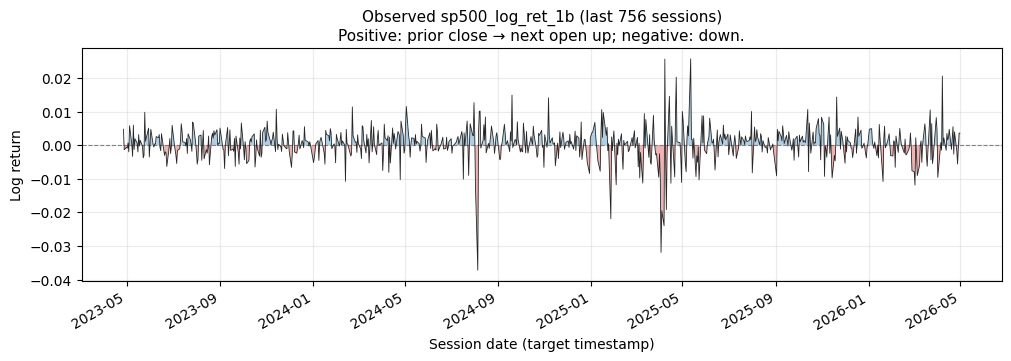

In [17]:
fig, _ = plot_sp500_log_return_recent(svc_no_cov, n_trading_days=756)
plt.show()



---
## 6. Task and backtest window

The evaluation window is driven by **DEMO CONFIG** (`SPEC_*`).  Printing
`describe_spec` keeps the notebook self-documenting (same spirit as the
Canada food CPI experiment).



In [18]:
task = ForecastingTask(
    task_id="sp500_log_return_1b",
    target_series_id=SP500_LOG_RETURN_SERIES_ID,
    horizons=[1],
    frequency="B",
    description="Forecast next-session open vs prior close S&P500 log return.",
)

spec = BacktestSpec(
    task=task,
    start=SPEC_START,
    end=SPEC_END,
    stride=SPEC_STRIDE,
    warmup=SPEC_WARMUP,
    description="Multivariate demo; models chosen in DEMO CONFIG.",
)

print(describe_spec(spec, data_service=svc_cov))
spec



BacktestSpec
  description: Multivariate demo; models chosen in DEMO CONFIG.
  start:       2020-03-01 00:00:00
  end:         2021-03-01 00:00:00
  stride:      1
  warmup:      252

Task: sp500_log_return_1b
  description: Forecast next-session open vs prior close S&P500 log return.
  horizons:    1
  frequency:   B
  resolution:  observed_value_at_resolution_timestamp
- target_series_id: sp500_log_ret_1b
    description:    S&P 500 log return from prior session adjusted close to current session open (Yahoo Finance ^GSPC)
    source:         Yahoo Finance (^GSPC), derived
    units:          log-return
    frequency:      B


BacktestSpec(task=ForecastingTask(task_id='sp500_log_return_1b', target_series_id='sp500_log_ret_1b', horizons=[1], frequency='B', description='Forecast next-session open vs prior close S&P500 log return.', resolution_fn='observed_value_at_resolution_timestamp'), start=datetime.datetime(2020, 3, 1, 0, 0), end=datetime.datetime(2021, 3, 1, 0, 0), stride=1, warmup=252, description='Multivariate demo; models chosen in DEMO CONFIG.')

---
## 7. Backtests — one row per enabled model

Each `True` entry in `RUN_MODELS` runs a full `backtest` (one fit per origin).
The table below is sorted by **mean CRPS** (lower is better).



In [19]:
def _direction_metrics_row(*, predictions, svc) -> dict[str, float]:
    """Point-forecast up/down vs realized sign; precision = sklearn precision on positive class."""
    eval_df = build_direction_eval_frame(
        predictions,
        target_series_id=SP500_LOG_RETURN_SERIES_ID,
        data_service=svc,
    )
    if eval_df.empty:
        return {
            "dir_precision_up": float("nan"),
            "dir_recall_up": float("nan"),
            "dir_f1_up": float("nan"),
            "dir_accuracy": float("nan"),
            "dir_roc_auc_prob_up": float("nan"),
            "dir_n_eval": 0,
        }
    m = direction_classification_metrics(eval_df)
    return {
        "dir_precision_up": float(m.get("precision_up", float("nan"))),
        "dir_recall_up": float(m.get("recall_up", float("nan"))),
        "dir_f1_up": float(m.get("f1_up", float("nan"))),
        "dir_accuracy": float(m.get("accuracy", float("nan"))),
        "dir_roc_auc_prob_up": float(m.get("roc_auc_prob_up", float("nan"))),
        "dir_n_eval": int(m.get("n", 0)),
    }


def _run_one_row(*, run_key: str, predictor, svc) -> dict[str, object]:
    result = backtest(
        predictor=predictor,
        spec=spec,
        data_service=svc,
        show_progress=SHOW_BACKTEST_PROGRESS,
    )
    uses_cov = run_key.endswith("with_covariates")
    cov_ids = selected_covariates if uses_cov else []
    dir_row = _direction_metrics_row(predictions=result.predictions, svc=svc)
    return {
        "run_key": run_key,
        "model": run_key.replace("_", " "),
        "uses_covariates": uses_cov,
        "n_covariates": len(cov_ids),
        "covariates": ", ".join(cov_ids) if cov_ids else "—",
        "predictor_id": result.predictor_id,
        "mean_crps": float(result.mean_crps),
        "n_scores": int(len(result.scores)),
        "n_predictions": int(len(result.predictions)),
        "skipped_origins": int(result.skipped_origins),
        **dir_row,
        "error": "",
    }


def _predictor_for(run_key: str):
    if run_key == "linreg_target_only":
        return DartsLinearRegressionPredictor(
            lags=QUICK_LAGS,
            covariate_series_ids=None,
            num_samples=QUICK_NUM_SAMPLES,
        )
    if run_key == "linreg_with_covariates":
        return DartsLinearRegressionPredictor(
            lags=QUICK_LAGS,
            lags_past_covariates=QUICK_LAGS_PAST_COV,
            covariate_series_ids=selected_covariates,
            num_samples=QUICK_NUM_SAMPLES,
        )
    if run_key == "lightgbm_target_only":
        return DartsLightGBMPredictor(
            lags=QUICK_LAGS,
            covariate_series_ids=None,
            num_samples=QUICK_NUM_SAMPLES,
            lgbm_kwargs=dict(LIGHTGBM_KWARGS),
        )
    if run_key == "lightgbm_with_covariates":
        return DartsLightGBMPredictor(
            lags=QUICK_LAGS,
            lags_past_covariates=QUICK_LAGS_PAST_COV,
            covariate_series_ids=selected_covariates,
            num_samples=QUICK_NUM_SAMPLES,
            lgbm_kwargs=dict(LIGHTGBM_KWARGS),
        )
    if run_key == "arima_target_only":
        return DartsARIMAPredictor(
            p=QUICK_ARIMA_P,
            d=QUICK_ARIMA_D,
            q=QUICK_ARIMA_Q,
            num_samples=QUICK_NUM_SAMPLES,
        )
    if run_key == "varima_with_covariates":
        return DartsVARIMAPredictor(
            covariate_series_ids=selected_covariates,
            p=QUICK_VARIMA_P,
            d=QUICK_VARIMA_D,
            q=QUICK_VARIMA_Q,
            num_samples=QUICK_NUM_SAMPLES,
        )
    raise KeyError(f"Unknown run_key: {run_key!r}")


def _service_for(run_key: str):
    if run_key in ("linreg_target_only", "lightgbm_target_only", "arima_target_only"):
        return svc_no_cov
    if run_key in ("linreg_with_covariates", "lightgbm_with_covariates", "varima_with_covariates"):
        return svc_cov
    raise KeyError(run_key)


_nan_dir = {
    "dir_precision_up": float("nan"),
    "dir_recall_up": float("nan"),
    "dir_f1_up": float("nan"),
    "dir_accuracy": float("nan"),
    "dir_roc_auc_prob_up": float("nan"),
    "dir_n_eval": 0,
}

rows: list[dict[str, object]] = []
for run_key, enabled in RUN_MODELS.items():
    if not enabled:
        continue
    try:
        pred = _predictor_for(run_key)
        svc = _service_for(run_key)
        rows.append(_run_one_row(run_key=run_key, predictor=pred, svc=svc))
    except Exception as exc:
        uses_cov = run_key.endswith("with_covariates")
        rows.append(
            {
                "run_key": run_key,
                "model": run_key.replace("_", " "),
                "uses_covariates": uses_cov,
                "n_covariates": len(selected_covariates) if uses_cov else 0,
                "covariates": ", ".join(selected_covariates) if uses_cov else "—",
                "predictor_id": "error",
                "mean_crps": float("nan"),
                "n_scores": 0,
                "n_predictions": 0,
                "skipped_origins": 0,
                **_nan_dir,
                "error": str(exc),
            }
        )

RESULTS_DF = pd.DataFrame(rows).sort_values("mean_crps", na_position="last")



darts_varima: 100%|██████████| 261/261 [1:51:03<00:00, 25.53s/origin]


---
## 8. Leaderboard — formatted table and CRPS chart



,run_key,model,uses_covariates,n_covariates,covariates,predictor_id,mean_crps,n_scores,n_predictions,skipped_origins,dir_precision_up,dir_recall_up,dir_f1_up,dir_accuracy,dir_roc_auc_prob_up,dir_n_eval,error
3,lightgbm_with_covariates,lightgbm with covariates,True,4,"vix_level_l1b, vix_log_ret_1b_l1b, nasdaq_log_ret_1b_l1b, ust2y10y_spread_l1b",darts_lightgbm_cov,0.00519,252,252,9,0.636,0.783,0.702,0.599,0.532,252,
2,lightgbm_target_only,lightgbm target only,False,0,—,darts_lightgbm,0.00523,252,252,9,0.622,0.737,0.675,0.571,0.553,252,
1,linreg_with_covariates,linreg with covariates,True,4,"vix_level_l1b, vix_log_ret_1b_l1b, nasdaq_log_ret_1b_l1b, ust2y10y_spread_l1b",darts_linreg_cov,0.00592,252,252,9,1.000,0.007,0.013,0.401,0.539,252,
0,linreg_target_only,linreg target only,False,0,—,darts_linreg,0.00593,252,252,9,0.000,0.000,0.000,0.397,0.515,252,
5,varima_with_covariates,varima with covariates,True,4,"vix_level_l1b, vix_log_ret_1b_l1b, nasdaq_log_ret_1b_l1b, ust2y10y_spread_l1b",darts_varima,0.00650,252,252,9,0.674,0.395,0.498,0.520,0.552,252,
4,arima_target_only,arima target only,False,0,—,darts_arima,0.00660,252,252,9,0.607,0.954,0.742,0.599,0.507,252,


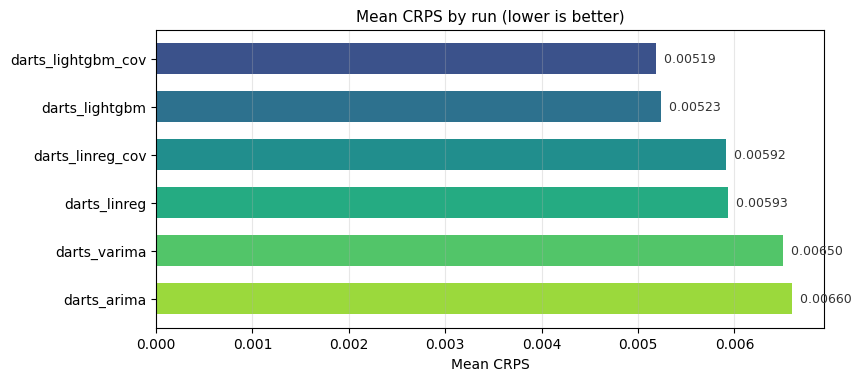

In [20]:
from IPython.display import display

if RESULTS_DF.empty:
    print(
        "RESULTS_DF is empty — set at least one entry to True in RUN_MODELS (DEMO CONFIG cell)."
    )
else:
    display(style_results_dataframe(RESULTS_DF))
    fig, _ = plot_mean_crps_leaderboard(RESULTS_DF)
    plt.show()


---
## 9. Operational notes

- **LightGBM:** `DartsLightGBMPredictor` caps OpenMP/BLAS/joblib threads and defaults
  `n_jobs`/`num_threads` to 1 to avoid nested-parallelism crashes on macOS. You still
  need **`brew install libomp`** if import fails with a missing `libomp.dylib`. If the
  kernel still dies, keep LightGBM rows `False` and use linear models only.
- **ARIMA / VARIMA:** `DartsARIMAPredictor` is fixed-order univariate ARIMA; `DartsVARIMAPredictor`
  fits a VARIMA on `[target] + covariates` (joint dynamics) and scores only the target
  component. Both are slower per origin than linear regression; enable with `RUN_MODELS`.
  For automatic order search, import `DartsAutoARIMAPredictor` from `methods.darts_arima`.
- Widen `SPEC_*` and raise `QUICK_LAGS` / `QUICK_NUM_SAMPLES` for heavier, more
  stable estimates.

